# Decoding PicoQuant TTTR Files (.ptu) and Fit Fluorescence Decays

This script deals with decoding of PicoQuant TTTR files (.ptu) produced by HydraHarp V2. First, the header section is decoded to gain necessary information for proper decoding of the photon record data and the actual microscope image, i.e. the position in x and y where a particular photon record was made. Second, the photon recond data are read and sorted into a 3D array. This array holds the fluorescence decay curves of each pixel and are subsequently fitted to obtain fluorescence lifetimes.

**In this script, only HydraHarp V2 TTTR data are treated and decoded. However, it can easily be expanded to also cover different PicoQuant TCSPC hardware.**

This script is based on PicoQuants' .ptu decoding example (https://github.com/PicoQuant/PicoQuant-Time-Tagged-File-Format-Demos/blob/master/PTU/Python/Read_PTU.py) and an adaption of that script for the PhasorFLIM application written in JavaScript (https://github.com/Tomkaehst/PhasorFLIM/blob/master/app/filedecoding/PTUReaderBitwise.js).


## PTU File Architecture

*.ptu* files consist of a header and record section. In the header, information about the FLIM system and imaging parameters are stored, which are required in order to reconstruct FLIM images from the single photon data encoded in the record section.

### File Magic

*.ptu* files can be identified and verified by the file magic string encoded in the first eight bytes. It should read ```PQTTTR```. The next eight bytes contain the file version (see ).

After file verification, header tags of different data types are read out. The header end is indicated by "Header_End" and can be searched for to know when to stop decoding it. Header data types are indicated by type code tags in each 48 byte header data piece. It is checked to decide what data type should be extracted from the binary file. To read the photon record data from the following file section, the record type has to be known. This is also encoded in the header section.

In [5]:
import sys, struct, io, os
import math
import numpy as np
from numba import jit
from scipy.optimize import curve_fit
from scipy.integrate import odeint
%matplotlib inline 
import matplotlib.pyplot as plt

ptupath = 'app/testData/EGFP_Cherry_Co_1_1.ptu'
ptureadstream = open(ptupath, 'rb')

filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

# Checking file valiidy by reading file magic and file version
if(filemagic != 'PQTTTR'):
    print('%s is not a .ptu file!' % ptupath)
    ptureadstream.close()
else:
    print('%s is a valid .ptu file... Commencing.' % ptupath)

    
fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
print('File Version: %s' % fileversion)

app/testData/EGFP_Cherry_Co_1_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00


In [6]:
# Adjusting figure size of subsequent plots
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 10
fig_size[1] = 8
plt.rcParams["figure.figsize"] = fig_size

### PTU File Header & Record Tag Type Definitions

In [7]:
# Definition of header tag types

tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

# Defining record types

rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]

## Decoding Header Information
In the first file segment, information about the measurement are encoded in different data types (see PicoQuant TTTR documententation in GitHub repository above).
Each header piece has 48 bytes. 

- 0:32 holds the tag ID (e.g. filename, image dimensions, ...)
- 32:36 holds the tag index
- 36:40 holds tag data type identifier (see above)
- 40:48 holds actual tag value

The header is read in 48 byte chunks until the header end tag is encounterd. The detected tag data type decides how a header piece is treated. If a string is identified, the tag value variable indicates in how many bytes the string in encoded. After treatment, header chunks are stored in the header_contents dictionary.

In [8]:
## setting up header end string to terminate header decoding in while loop 
headerend_tag = 'Header_End'
reached_headerend = False


# tuple that stores decoded information from header section
header_contents = {}

# decoding header
while(reached_headerend == False):
    headerpiece = ptureadstream.read(48)
    tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
    tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
    tagType = struct.unpack('<i', headerpiece[36:40])[0]
    tagVal = headerpiece[40:48]
    
    if(tagId == headerend_tag):
        reached_headerend = True
        ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
        print('Found Header_End.')
        break
    
    if(tagType == tyEmpty8):
        header_contents['Empty'] =  'Empty'
        
    elif(tagType == tyBool8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyInt8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8):
        value = struct.unpack('<d', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8Array):
        value = struct.unpack("<q", tagVal)[0]
        print('Float array with %d entries' % value / 8)
        
    elif(tagType == tyAnsiString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('latin1').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyWideString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyBinaryBlob):
        value = struct.unpack("<q", tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyBitSet64):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyColor8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  "{0:#0{1}x}".format(value,18)
        
    elif(tagType == tyBinaryBlob):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value

    elif(tagType == tyTDateTime):
        print(' ')
        
    else:
        continue
        #print('Unknown header tag type. Ignored.')
        
    
headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header
    
print('Finished decoding header.')

 
Found Header_End.
Finished decoding header.


The releveant header information is now copied into a new structure for convinient access.
In order to reconstruct the FLIM image, several value are required

- Filename: Filename
- Comment: String containing user comments
- TTResultsFormat_TTTRRecType: Type of the photon records i.e. which device was used
- TTResultFormat_BitsPerRecord: Number of bits in a photon record
- ReqHdr_SpatialResolution: Width of a pixel in µm
- ImgHdr_PixX: How many pixels in X?
- ImgHdr_PixY: How many pixels in Y?
- MeasDesc_GlobalResolution: time resolution of measurement
- HW_BaseResolution: Principal time resolution of device
- MeasDesc_Resolution: TCSPC resolution, also obtained by BaseResolution * BinningFactor
- MeasDesc_BinningFactor: Binning factor
- TTResult_SyncRate: Laser pulse / Sync rate of measurement
- TTResult_NumberOfRecords: How many 32 bit records in file?

In [9]:
FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
}
FLIMInfo

{'Filename': 'EGFP_Cherry_Co_1_1',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 2.1623884549626382e-07,
 'PixelsX': 1024,
 'PixelsY': 1024,
 'GlobalResolution': 5.141430469350905e-08,
 'BaseResolution': 9.999999960041972e-13,
 'Resolution': 1.5999999936067155e-11,
 'BinningFactor': 16,
 'SyncRate': 19449840,
 'NumberOfRecords': 3153288}

## Decoding Photon Records
After header reading, we have sufficient information to decode the photon data from the ```.ptu``` file. **Because in this script, only HydraHarp V2 TTTR data are decoded**, only this record type is considered.

### Photon Data Architecture
A HydraHarp V2 TTTR record has 32 bits and encodes three types of information:
- marker
    - Indicates channel in which photon was detected, of regular photon record occured
    - Indicates several special records
        - macro time overflow
        - frame and line start or stop
- macro time
- nano time


#### Meaning of Marker Events

The marker stream consists of two elements: the special bit and the channel bits. The special bit is the first bit of each 32 bit photon record. When it is set it indicates that the record is not a photon, but a system marker event: line start (65 = 1000001), line stop (67 = 1000010), or an macrotime clock overflow (127 = 1111111).
When the special bit is not set, the channel bits indicate the channel number in which the photon event was registered.
In the case of an macrotime bit overflow, the nanotime bits encode the number of times an overflow has occured so far. This is required to calculate the real macrotime of the experiment.

In [10]:
ptureadstream.close()

### Rewriting *.ptu* Decoding with NumPy 
Only photon record section for now. Byte offset until photon records saved above after ```Header_End``` tag has been detected.

In [11]:
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(recordarray)
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
        #record['macrotime'] = (
        #    overflow_cor + np.bitwise_and(record['record'], 1023)) * macrotimefactor

    return(recordarray)

In [12]:
## Trying to use NumPy for binary decoding and processing

# Initializing numpy array holding photon data
## record: raw TCSPC data from binary file, UInt32, see PicoQuant
## marker:
## nanotime:
## macrotime:

recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8), ('nanotime', np.float64), ('macrotime', np.float64)])


# Preallocating array with decoded raw FLIM data
recordarray = np.zeros(shape = FLIMInfo['NumberOfRecords'] - 1,dtype = recordBitType)

# Factors required to recover real macro and nanotimes from raw photon data stream
macroMultFactor = FLIMInfo['GlobalResolution'] # Multiply with truensync to get experiment macro time
nanoMultFactor = FLIMInfo['Resolution'] * 1e9


# Opening .ptu file and shoveling it into UInt32 section of preallocated array
with open(ptupath, 'rb') as file:
    file.seek(headerend_bitoffset)
    recordarray[:]['record'] = np.fromfile(file, dtype = np.uint32)
    file.close()
    
# Recover marker signals and nanotimes of photon events
recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
recordarray[:]['nanotime'] = (np.right_shift(
        recordarray[:]['record'], 10) & 32767) * nanoMultFactor

# Recover macrotimes and treat overflows
recordarray = treatOverflows(recordarray, macroMultFactor)

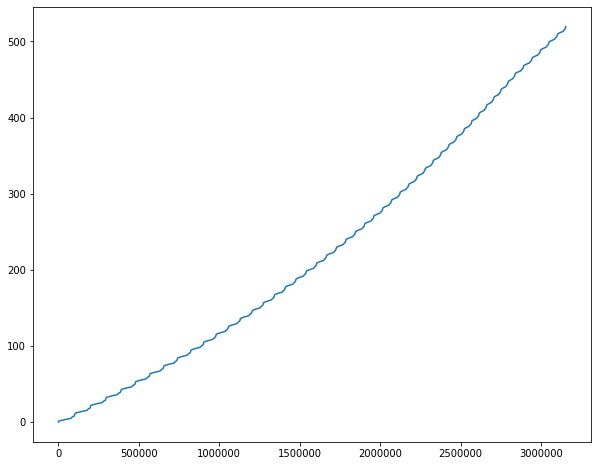

In [13]:
# Checking if macrotime has been properly corrected. If so, it increases over number of events.
plt.plot(recordarray['macrotime'])
plt.show()

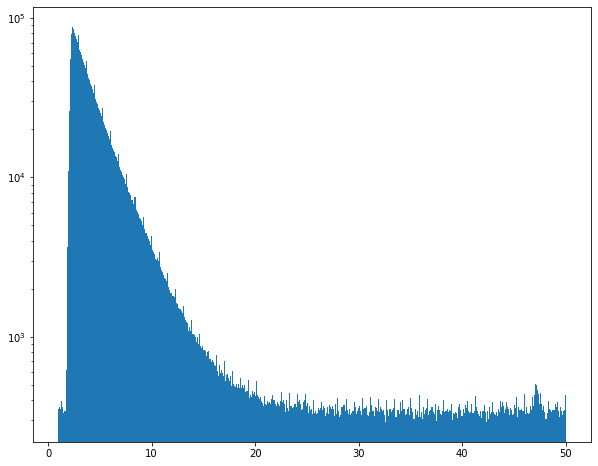

In [14]:
plt.hist(recordarray['nanotime'], bins=500, range = (1, 50), log = "y")
plt.show()

## Reconstructing Image from Data Stream

In [15]:
# Counting number of lines

def countLines(recordarray):
    numLinesStart = np.sum(recordarray['marker'] == 65)
    numLinesStop = np.sum(recordarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [16]:
def checkChannelAvailability(recordarray):

    channelList = []

    if(np.any(recordarray['marker'] == 0)):
        channelList.append(0)
        
    if(np.any(recordarray['marker'] == 1)):
        channelList.append(1)
        
    if(np.any(recordarray['marker'] == 2)):
        channelList.append(2)
        
    if(np.any(recordarray['marker'] == 3)):
        channelList.append(3)
    
    print("Detected channels: ", channelList)

    return channelList

In [17]:
FLIMInfo['channelList'] = checkChannelAvailability(recordarray)

Detected channels:  [0, 1]


In [18]:
FLIMInfo['LinesInFile'] = countLines(recordarray)

In [19]:
FLIMInfo

{'Filename': 'EGFP_Cherry_Co_1_1',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 2.1623884549626382e-07,
 'PixelsX': 1024,
 'PixelsY': 1024,
 'GlobalResolution': 5.141430469350905e-08,
 'BaseResolution': 9.999999960041972e-13,
 'Resolution': 1.5999999936067155e-11,
 'BinningFactor': 16,
 'SyncRate': 19449840,
 'NumberOfRecords': 3153288,
 'channelList': [0, 1],
 'LinesInFile': 51200}

In [20]:
@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):    
    eventCounter = 0 # Keeps track of photon / marker events while looping through data
    lineCounter = 0 # Stores current scan line numbers
    frameCounter = 0 # Stores current frame number
    framesInFile = linesinfile / pixelsx # How many frames are in the image; assume square format
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning)) # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    globalResolution = globRes * 10E8 # time between pulses in ns
    timeResolution = timeRes * 10E9 # TCSPC time resolution in nss
    
    
    binningFactor = 2**spatialBinning
    print(binningFactor)
    
    lineStart = 0
    lineStop = 0
    pixelTime = 0 # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    lastLine = False # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lineActive = False # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)

    tmpEvents = [np.float64(x) for x in range(0)] # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpNano = [np.float64(x) for x in range(0)] # List storing photon nanotimes to assign to 3D-FLIM array in x-y position 
    tmpMarker = 0 # Holds marker value for one loop iteration
    tmpMacro = 0 # Holds macrotime value for one loop iteration
    tmpNanotime = 0 # Holds nanotime value for one loop iteration
    diff = 0 # Stores difference between photon macro time and line start to determine photon y-position
    oorPhotons = 0 # Count out-of-range photons (photons with macrotime below or above line time difference)
    
    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0 # Current x position in image
    pixelIDY = 0 # Current y position in image
    
    
    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype = np.uint16)
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16) # 2D array for intensity image

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65): # Event is line start marker
            lineActive = True # Starting line evaluation (next while loop)
            lineStart = recordarray['macrotime'][eventCounter] # Store line start time
            eventCounter += 1
            continue # Skip this loop iteration

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)
                
                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins)

                    if(pixelIDY < 0 or pixelIDY > nPixelY):
                        oorPhotons = oorPhotons + 1
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1



    print("Assigned photons to pixels.\n",
          (oorPhotons / np.sum(intensityImage))*100,
          "% of photons were out of range... Total:", oorPhotons, "of", np.sum(intensityImage), "photons.")



    return flimarray, intensityImage

In [21]:
flimarray, intimage = buildFLIMArray(recordarray,
                                     0,
                                     FLIMInfo['LinesInFile'],
                                     FLIMInfo['PixelsX'],
                                     FLIMInfo['PixelsY'],
                                     FLIMInfo['GlobalResolution'],
                                     FLIMInfo['Resolution'],
                                     2,
                                     3)
recordarray = None # dereferencing recordarray for garbage collection; in the future: ptu processing via data stream!

4
Assigned photons to pixels.
 0.0 % of photons were out of range... Total: 0 of 2004032 photons.


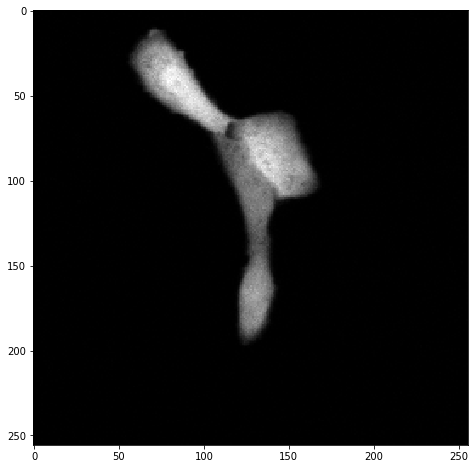

In [22]:
plt.imshow(intimage, cmap = "gray")

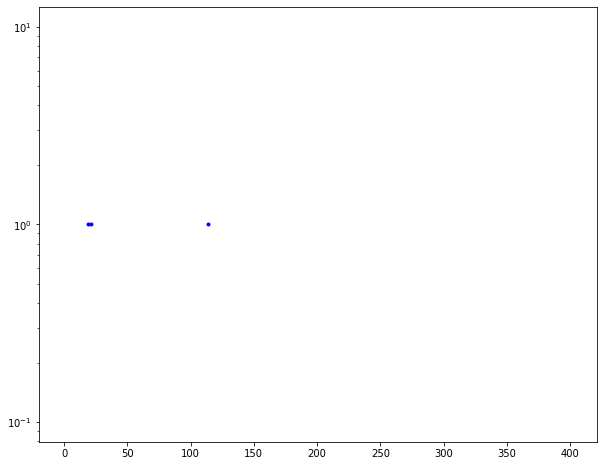

(array([ 19,  21, 114]),)

In [23]:
plt.plot(flimarray[20][35][:], 'b.')
plt.yscale("log")
plt.show()
np.where(flimarray[20][35][:] == max(flimarray[20][35][:]))

## Data Fitting
The functions above produced two arrays, one holding the intensity image (2D, intImg) and one holding the fluorescence decays (3D, flimarray).

As a first attempt, the fluorescence lifetimes of the image are determined by tail fitting. Iterative reconvolution and model-based fitting is implemented bases upon that.

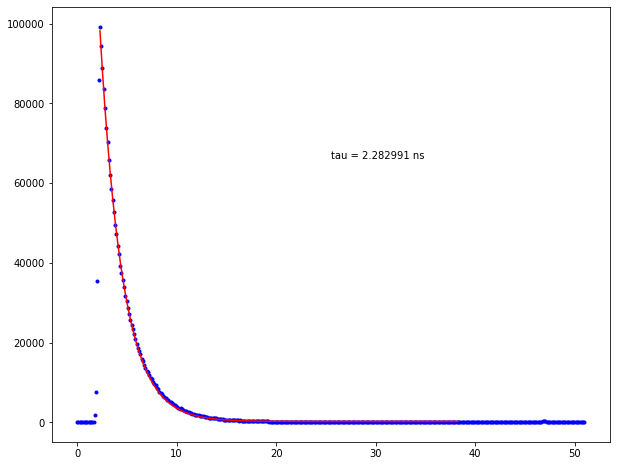

In [24]:
# Simple exponential decay


def expDecay(x, a, b, tau):
    return(a * np.exp(-x/tau) + b)

overallDecay = np.sum(np.sum(flimarray, axis=0), axis = 0) # There's definitely a smarter way to do this.

xaxis = np.linspace(0, round(FLIMInfo['GlobalResolution']*10E8), flimarray.shape[2])
maxVal = np.where(overallDecay == max(overallDecay))[0][0]
endOfData = overallDecay.size - 100

## Sum decay of whole image

plt.plot(xaxis, overallDecay, 'b.')
#plt.yscale("log")

tau_fit, tau_cov = curve_fit(expDecay, xaxis[maxVal:endOfData], overallDecay[maxVal:endOfData])
plt.text(1/2*max(xaxis), 2/3*max(overallDecay), "tau = %f ns" % tau_fit[2])
plt.plot(xaxis[maxVal:endOfData], expDecay(xaxis, *tau_fit)[maxVal:endOfData], 'r-')

### Pixel-wise Fitting (Paralellized with Numba)




In [104]:
from numba import prange, njit # njit is short-hand for @jit(nopython=True)


def expDecay(x, a, b, tau):
    return(a * np.exp(-x/tau) + b)

#@njit()
def pixelwiseSimpleDecay(flimarray, photonthreshold, rightcutoff, globRes):
    '''
        Function: pixelwiseSimpleDecay(
            - flimarray: 3D array x-y-ns holding fluorescence decays for each image pixel
            - photonthreshold: number of photons in pixel required to start fitting
            - rightcuttoff: how much data of decay to exclude from the right side of the curve
            - globRes: FLIMInfo['GlobalResolution'], required to reconstruct time axis with correct time (in ns)
        )
    '''
    numDecaysX = flimarray.shape[0]
    numDecaysY = flimarray.shape[1]
    print(numDecaysX, numDecaysY)
    
    lifetimeImage = np.zeros((numDecaysX, numDecaysY), dtype = np.int8)
    tau_fit = []
    
    for x in prange(numDecaysX):
        for y in range(numDecaysY):
            if(flimarray[x][y][:].sum() > photonthreshold):
                xaxis = np.linspace(0, round(globRes*10E8), flimarray.shape[2])
                maxVal = np.where(flimarray[x][y] == max(flimarray[x][y]))[0][0]
                endOfData = flimarray[x][y].size - rightcutoff
                tau_fit = curve_fit(expDecay, xaxis[maxVal:endOfData], flimarray[x][y][maxVal:endOfData])
                lifetimeImage[x][y] = tau_fit[2]
            #else:
                #print("Position (", x, y, ") has not enough photons for fitting...")
        
    
    return(lifetimeImage)

In [105]:
fittedImage = pixelwiseSimpleDecay(flimarray, 150, 10, FLIMInfo['GlobalResolution'])

256 256


IndexError: tuple index out of range

In [115]:
fittedImage = np.zeros((flimarray.shape[0], flimarray.shape[1]), dtype = np.int16)
fittedImage.size*fittedImage.itemsize

4294967296

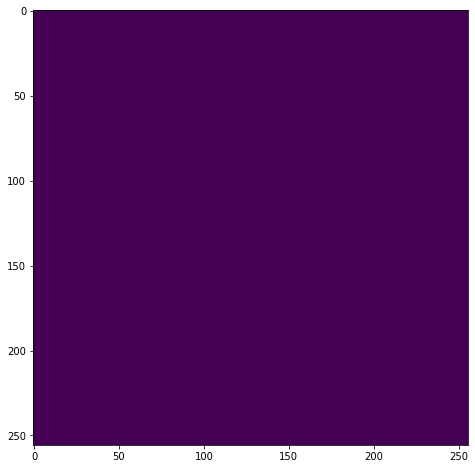

In [114]:
plt.imshow(fittedImage, cmap = "viridis")

## Fitting with ODEs

[2.58893455]


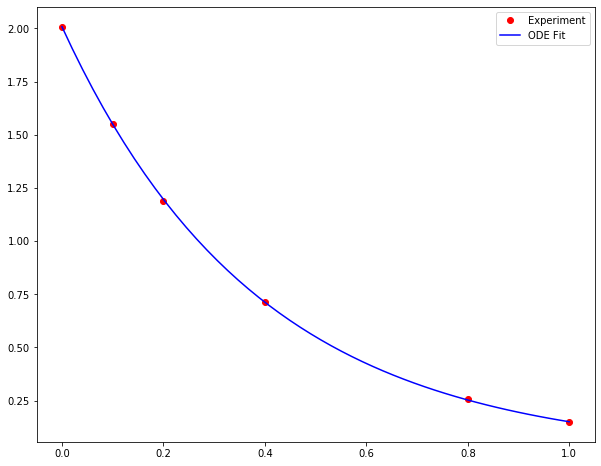

In [36]:
# ODE Fitting in NumPy/SciPy
t = [0, 0.1, 0.2, 0.4, 0.8, 1]
Ca_data = [2.0081, 1.5512, 1.1903, 0.7160, 0.2562, 0.1495]

def fitfunc(t, k):
    def myode(Ca, t):
        return -k * Ca
    
    Ca0 = Ca_data[0]
    Casol = odeint(myode, Ca0, t)
    return Casol[:, 0]

k_fit, k_cov = curve_fit(fitfunc, t, Ca_data, p0 = 1.3)
print(k_fit)

tfit = np.linspace(0, 1);
fit = fitfunc(tfit, k_fit)

plt.plot(t, Ca_data, 'ro', label = "Experiment")
plt.plot(tfit, fit, 'b-', label = "ODE Fit")
plt.legend(loc = "best")
plt.show()

In [37]:
def gauss_laser(t, amp, dplace, grsm):
    y = amp * np.exp(-(t - dplace)**2 / (2 * grsm**2))
    return(y)

def mono_decay(t):#, tau, laserAmp, laserDplace, laserGRSM):
    D0 = 100000
    D1 = 0
    time = t
    f = 1/2.5
    
    laser = gauss_laser(time, 1, 10, 2.5)
    
    dD1 = -f * D1 + laser
    dD0 = -dD1
    
    return(dD0, dD1)

In [38]:
t_test = np.linspace(0.0, 100.0, 1000)
laser_test = gauss_laser(t_test, 1, 10, 2.5)

In [39]:
test_int = odeint(mono_decay, [0], t_test)

TypeError: mono_decay() takes 1 positional argument but 2 were given